# Choosing k for the `cluster` labeling strategy

Generic and species-agnostic, like the rest of this repo's notebooks. This
notebook is a PRE-labeling step: it exists to help pick a defensible
`n_clusters` before calling `labelers.cluster()` for real (either directly
or via `scripts/run_pipeline.py --label-strategy cluster --n-clusters ...`).
It does not run the real clustering-for-labeling step itself, and it never
writes anything to disk.

Mirrors the workflow taught in the lab's own hierarchical-clustering
material (2023-DG-DataProcessing-11): inspect the raw distribution, run an
elbow curve and a silhouette-score curve across a range of k, pick a
candidate, check that candidate's per-sample silhouette coefficients, then
look at the dendrogram. Choosing k is a human judgment call informed by
these diagnostics, not something this notebook decides automatically.

In [1]:
# ---------------------------------------------------------------------------
# Configuration -- the only cell that needs editing for a different dataset.
# Everything below is generic.
# ---------------------------------------------------------------------------

# Path to a gene-level TSV (plain or .gz), same shape as scripts/run_pipeline.py expects.
INPUT_TABLE = "/mnt/f/RA/Downstream/Project1_polysomelongread_PR/CR_3D.PR.gene_data.tsv.gz"

ID_COL = "gene_id"
STRIP_ID_SUFFIX = r"\.v\d+\.\d+$"   # set to None if IDs need no normalization
EXCLUDE_IDS = ["gene:Standard-R-luc"]

# One or more numeric columns to cluster on. A single column (e.g. PR_gene
# alone) is a 1D clustering, the mechanism-only check described in the
# worked example. Multiple columns (e.g. PR values across several real
# conditions) is the original multi-condition use case this method was
# actually designed for.
METRIC_COLS = ["PR_gene"]

MAX_K_ELBOW = 15
K_RANGE_SILHOUETTE = range(2, 16)

In [10]:
import re
import gzip
import sys, os

_cwd = os.getcwd()
while not os.path.isdir(os.path.join(_cwd, "labelers")) and os.path.dirname(_cwd) != _cwd:
    _cwd = os.path.dirname(_cwd)
sys.path.insert(0, _cwd)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

from labelers.labelers import elbow_curve, silhouette_scores, sample_silhouette

opener = gzip.open if INPUT_TABLE.endswith(".gz") else open
with opener(INPUT_TABLE, "rt") as f:
    df = pd.read_csv(f, sep="\t", comment="#")

if STRIP_ID_SUFFIX:
    df[ID_COL] = df[ID_COL].apply(lambda g: re.sub(STRIP_ID_SUFFIX, "", g))
if EXCLUDE_IDS:
    df = df[~df[ID_COL].isin(EXCLUDE_IDS)]
df = df.dropna(subset=METRIC_COLS)

print(f"Loaded {len(df)} genes from {INPUT_TABLE}")
print(f"Clustering on: {METRIC_COLS}")
df[METRIC_COLS].describe()

Loaded 3593 genes from /mnt/f/RA/Downstream/Project1_polysomelongread_PR/CR_3D.PR.gene_data.tsv.gz
Clustering on: ['PR_gene']


,PR_gene
count,3593.000000
mean,0.857627
std,0.672277
min,0.000000
25%,0.555870
50%,0.833805
75%,1.042257
max,7.504249


## Raw distribution

The lab's own material checks the raw distribution before clustering, to
decide whether a transform is warranted. `labelers.cluster()` always
applies a Yeo-Johnson transform by default (it handles negative and zero
values, unlike a plain log transform, so it works unconditionally rather
than needing a per-dataset decision the way the lab's log-vs-raw choice
did). This plot is a sanity check, not a decision point: heavily skewed or
multimodal raw data is useful context for interpreting the elbow and
silhouette plots below, not something to act on directly.

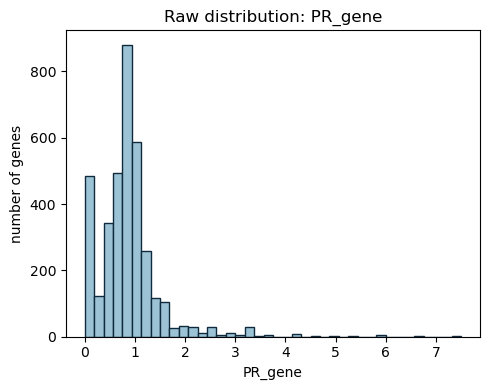

In [4]:
fig, axes = plt.subplots(1, len(METRIC_COLS), figsize=(5 * len(METRIC_COLS), 4), squeeze=False)
for ax, col in zip(axes[0], METRIC_COLS):
    ax.hist(df[col], bins=40, color="#9CC3D5", edgecolor="#0F2A3D")
    ax.set_xlabel(col)
    ax.set_ylabel("number of genes")
    ax.set_title(f"Raw distribution: {col}")
fig.tight_layout()
plt.show()

## Elbow curve

Within-cluster sum of squared errors (WSS) versus k. Look for the point
where the curve stops dropping sharply and starts to flatten ("the
bend") -- that's a candidate k, not a computed answer.

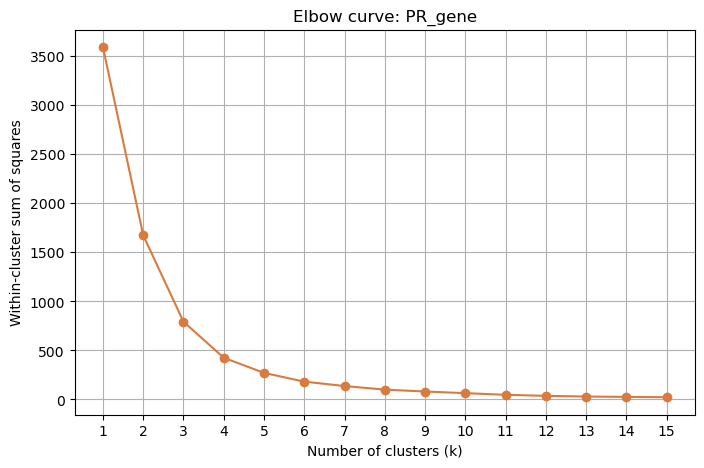

In [5]:
k_list, wss_list = elbow_curve(df, METRIC_COLS, max_k=MAX_K_ELBOW)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_list, wss_list, marker="o", color="#D97B3F")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Within-cluster sum of squares")
ax.set_title(f"Elbow curve: {', '.join(METRIC_COLS)}")
ax.set_xticks(k_list)
ax.grid(True)
plt.show()

## Silhouette score across k

A second, independent diagnostic. Higher is better-separated. Used
alongside the elbow curve, not instead of it -- the two can and sometimes
do disagree, which is itself useful information (a weakly-defined cluster
structure), not a bug.

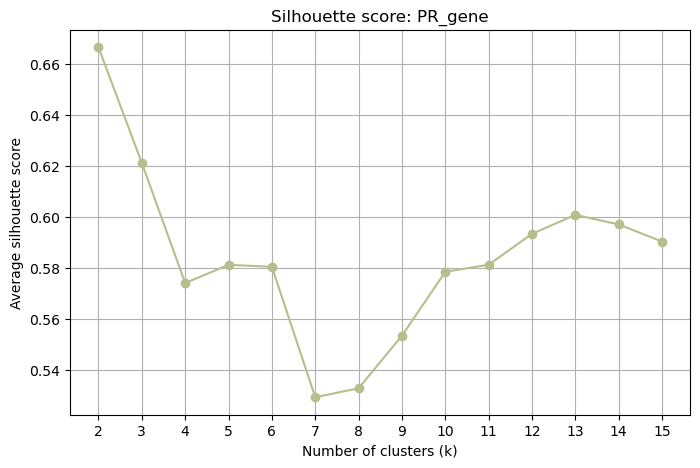

Top 5 candidate k by silhouette score:


,k,silhouette_score
0,2,0.666705
1,3,0.621256
11,13,0.600893
12,14,0.597121
10,12,0.593431


In [6]:
k_list_s, score_list = silhouette_scores(df, METRIC_COLS, k_range=K_RANGE_SILHOUETTE)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_list_s, score_list, marker="o", color="#B7BE8D")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Average silhouette score")
ax.set_title(f"Silhouette score: {', '.join(METRIC_COLS)}")
ax.set_xticks(k_list_s)
ax.grid(True)
plt.show()

score_table = pd.DataFrame({"k": k_list_s, "silhouette_score": score_list})
score_table = score_table.sort_values("silhouette_score", ascending=False)
print("Top 5 candidate k by silhouette score:")
display(score_table.head(5))

## Candidate k

Set this after looking at both plots above. This is a deliberate human
decision, not the output of a formula -- see the two cells below for how
to check whether this specific choice actually holds up.

In [14]:
CANDIDATE_K = 13  # <-- set based on the elbow curve and silhouette score above

## Per-sample silhouette at the candidate k

Checks whether THIS specific split is well separated, not just whether
its average score looked good above. Values near 1 = good fit, near 0 =
borderline, negative = likely misassigned. A candidate k with many
negative or near-zero values is a weaker choice even if its average
silhouette score looked reasonable in the curve above.

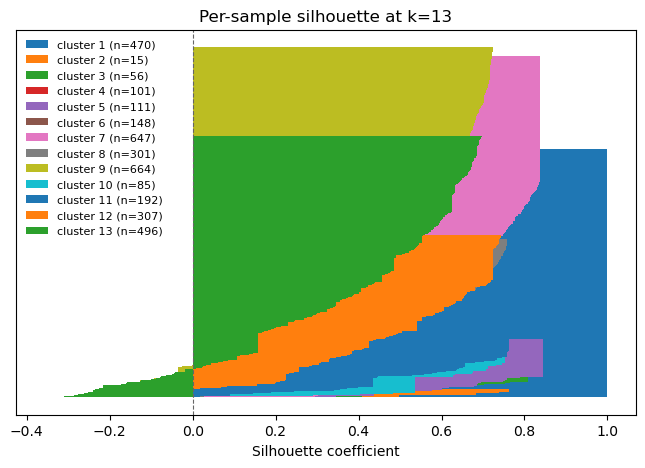

Per-cluster summary:


,count,mean,min
cluster,,,
1,470,1.000000,1.000000
2,15,0.638700,0.081503
3,56,0.655796,0.407361
4,101,0.434108,-0.085786
5,111,0.763917,0.344294
6,148,0.485027,-0.282673
7,647,0.700367,0.292128
8,301,0.563131,0.018704
9,664,0.438911,-0.273417


In [15]:
sil_df = sample_silhouette(df, METRIC_COLS, n_clusters=CANDIDATE_K)

fig, ax = plt.subplots(figsize=(8, 5))
for cluster_id in sorted(sil_df["cluster"].unique()):
    vals = sil_df.loc[sil_df["cluster"] == cluster_id, "silhouette"].sort_values()
    ax.barh(
        range(len(vals)), vals,
        left=0, height=1.0,
        label=f"cluster {cluster_id} (n={len(vals)})",
    )
ax.axvline(0, color="0.4", linestyle="--", linewidth=0.8)
ax.set_xlabel("Silhouette coefficient")
ax.set_yticks([])
ax.set_title(f"Per-sample silhouette at k={CANDIDATE_K}")
ax.legend(frameon=False, fontsize=8)
plt.show()

print("Per-cluster summary:")
display(sil_df.groupby("cluster")["silhouette"].agg(["count", "mean", "min"]))

## Dendrogram

For a 1D single-metric clustering (only one column in `METRIC_COLS`),
this can be dense with many genes -- consider it a structural sanity
check (does the tree show real substructure, or one dominant split) more
than something to read gene-by-gene at this scale.

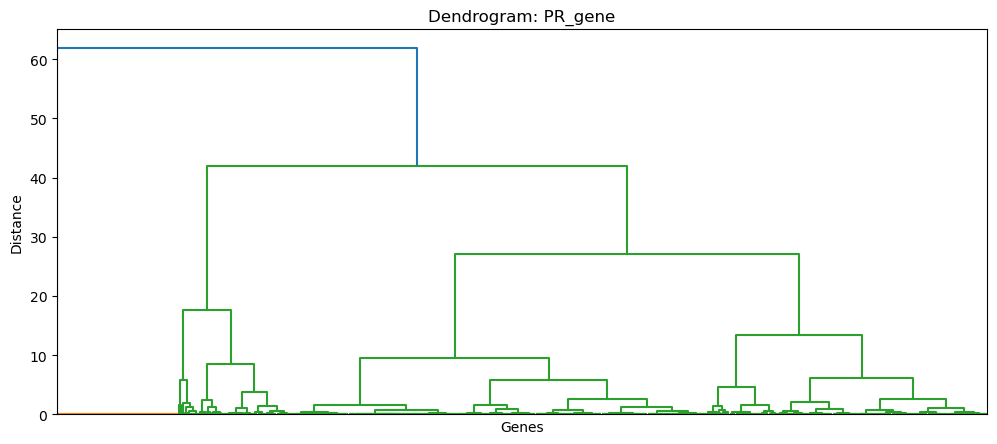

In [16]:
from scipy import stats as scipy_stats

data = df[METRIC_COLS].apply(lambda c: scipy_stats.yeojohnson(c)[0])
z = (data - data.mean()) / data.std()
link = linkage(pdist(z.values, metric="euclidean"), method="ward")

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(link, ax=ax, no_labels=True, color_threshold=None)
ax.set_xlabel("Genes")
ax.set_ylabel("Distance")
ax.set_title(f"Dendrogram: {', '.join(METRIC_COLS)}")
plt.show()

## Next step

Once `CANDIDATE_K` above is settled, use it directly:

```bash
python scripts/run_pipeline.py \
    --input-table <same path as INPUT_TABLE above> \
    --godb <path to .godb> \
    --metric-col <same as METRIC_COLS, single-column case> \
    --label-strategy cluster --n-clusters <CANDIDATE_K> \
    --output-dir results/GO \
    --dataset-name <run name>
```

This notebook never writes anything to disk, results only exist as an
in-memory record of the decision process, the CLI run above is what
produces real, versioned output files.